
# Домашнее задание 2.1. Двойной маятник

Цель работы — численно решить нелинейную задачу о двойном маятнике двумя явными методами:

1. методом Рунге–Кутты 4-го порядка (RK4);
2. методом Адамса–Бэшфорта 2-го порядка (AB2), причём первый шаг для AB2 делается методом RK4.

В первой части рассматриваются малые отклонения от нижнего положения равновесия и сравниваются результаты при нескольких шагах интегрирования. Во второй части начальные углы увеличиваются, и исследуется чувствительность решения к малым изменениям начальных условий.

В качестве дополнительной проверки численного решения используется полная механическая энергия. Для хаотического режима одной энергии недостаточно, поэтому отдельно проверяется сходимость по шагу.



## 1. Математическая модель

Углы $\theta_1$ и $\theta_2$ отсчитываются от вертикали вниз. Нижнее положение равновесия соответствует

$$
\theta_1 = \theta_2 = 0.
$$

### Параметры системы

$$
m_1 = m_2 = 1 \; \text{кг},
\qquad
l_1 = l_2 = 1 \; \text{м},
\qquad
g = 9.81 \; \text{м/с}^2.
$$

Состояние системы зададим вектором

$$
y =
\begin{pmatrix}
\theta_1 \\
\omega_1 \\
\theta_2 \\
\omega_2
\end{pmatrix},
$$

где

$$
\omega_1 = \dot{\theta}_1,
\qquad
\omega_2 = \dot{\theta}_2.
$$

Обозначим разность углов

$$
\Delta = \theta_1 - \theta_2.
$$

После составления уравнений Лагранжа и разрешения системы относительно угловых ускорений получаем

$$
\dot{\theta}_1 = \omega_1,
\qquad
\dot{\theta}_2 = \omega_2.
$$

Ускорение первого звена:

$$
\dot{\omega}_1 =
\frac{
-g(2m_1+m_2)\sin(\theta_1)
-m_2g\sin(\theta_1-2\theta_2)
-2m_2\sin(\Delta)
\left(l_2\omega_2^2+l_1\omega_1^2\cos(\Delta)\right)
}{
l_1\left(2m_1+m_2-m_2\cos(2\Delta)\right)
}
$$


In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import display, Image

g = 9.81
m1 = 1.0
m2 = 1.0
l1 = 1.0
l2 = 1.0

OUT = Path("double_pendulum_artifacts")
OUT.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True



## 2. Правая часть системы, энергия и координаты

Все ниже работают с одной и той же функцией правой части. Поэтому при сравнении методов меняется только численная схема, а физическая модель остаётся одной и той же.


In [2]:

def rhs(t, y):
    theta1, omega1, theta2, omega2 = y
    delta = theta1 - theta2

    den = 2*m1 + m2 - m2*np.cos(2*delta)

    alpha1 = (
        -g*(2*m1 + m2)*np.sin(theta1)
        -m2*g*np.sin(theta1 - 2*theta2)
        -2*m2*np.sin(delta) * (
            l2*omega2**2 + l1*omega1**2*np.cos(delta)
        )
    ) / (l1*den)

    alpha2 = (
        2*np.sin(delta) * (
            l1*omega1**2*(m1 + m2)
            + g*(m1 + m2)*np.cos(theta1)
            + l2*m2*omega2**2*np.cos(delta)
        )
    ) / (l2*den)

    return np.array([omega1, alpha1, omega2, alpha2], dtype=float)


def total_energy(Y):
    theta1, omega1, theta2, omega2 = Y.T

    kinetic = (
        0.5*(m1 + m2)*l1**2*omega1**2
        + 0.5*m2*l2**2*omega2**2
        + m2*l1*l2*omega1*omega2*np.cos(theta1 - theta2)
    )

    potential = (
        -(m1 + m2)*g*l1*np.cos(theta1)
        -m2*g*l2*np.cos(theta2)
    )

    return kinetic + potential


def bob_coordinates(Y):
    theta1 = Y[:, 0]
    theta2 = Y[:, 2]

    x1 = l1*np.sin(theta1)
    y1 = -l1*np.cos(theta1)

    x2 = x1 + l2*np.sin(theta2)
    y2 = y1 - l2*np.cos(theta2)

    return x1, y1, x2, y2


def lower_bob_distance(Y_a, Y_b):
    _, _, xa, ya = bob_coordinates(Y_a)
    _, _, xb, yb = bob_coordinates(Y_b)
    return np.sqrt((xa - xb)**2 + (ya - yb)**2)



## 3. Методы интегрирования

Для RK4 используется стандартная схема 4ого порядка
Для метода Рунге–Кутты 4-го порядка используется схема

$$
y_{n+1}
=
y_n
+
\frac{h}{6}
\left(
k_1+2k_2+2k_3+k_4
\right).
$$

Для метода Адамса–Бэшфорта второго порядка используется формула

$$
y_{n+1}
=
y_n
+
h
\left(
\frac{3}{2}f_n
-
\frac{1}{2}f_{n-1}
\right).
$$

Поскольку метод AB2 является многошаговым, для его запуска необходимо знать два последовательных значения решения. Поэтому первое значение $y_1$ вычисляется одним шагом метода RK4, после чего используется схема Адамса–Бэшфорта.


In [3]:

def rk4_step(t, y, h):
    k1 = rhs(t, y)
    k2 = rhs(t + h/2, y + h*k1/2)
    k3 = rhs(t + h/2, y + h*k2/2)
    k4 = rhs(t + h, y + h*k3)
    return y + h*(k1 + 2*k2 + 2*k3 + k4)/6


def integrate_rk4(y0, t_end, h):
    n = int(round(t_end / h))
    t = np.linspace(0.0, n*h, n + 1)
    Y = np.empty((n + 1, 4), dtype=float)
    Y[0] = y0

    for i in range(n):
        Y[i + 1] = rk4_step(t[i], Y[i], h)

    return t, Y


def integrate_ab2(y0, t_end, h):
    n = int(round(t_end / h))
    if n < 1:
        raise ValueError("Интервал должен содержать хотя бы один шаг.")

    t = np.linspace(0.0, n*h, n + 1)
    Y = np.empty((n + 1, 4), dtype=float)
    Y[0] = y0

    Y[1] = rk4_step(t[0], Y[0], h)

    f_prev = rhs(t[0], Y[0])
    f_curr = rhs(t[1], Y[1])

    for i in range(1, n):
        Y[i + 1] = Y[i] + h*(1.5*f_curr - 0.5*f_prev)
        f_prev, f_curr = f_curr, rhs(t[i + 1], Y[i + 1])

    return t, Y



# Часть I. Малые отклонения

В качестве начальных условий для режима малых отклонений выберем

$$
\theta_1(0)=0.15,
\qquad
\theta_2(0)=0.10,
$$

$$
\omega_1(0)=\omega_2(0)=0.
$$

Начальные углы составляют примерно

$$
\theta_1(0)\approx 8.6^\circ,
\qquad
\theta_2(0)\approx 5.7^\circ.
$$

Для сравнения точности численных методов используются следующие шаги интегрирования:

$$
h = 0.04,\; 0.02,\; 0.01,\; 0.005 \; \text{с}.
$$

In [4]:

y0_small = np.array([0.15, 0.0, 0.10, 0.0])
T_small = 20.0
steps_small = [0.04, 0.02, 0.01, 0.005]

small_rk4 = {h: integrate_rk4(y0_small, T_small, h) for h in steps_small}
small_ab2 = {h: integrate_ab2(y0_small, T_small, h) for h in steps_small}

h_show = 0.01
t_rk, Y_rk = small_rk4[h_show]
t_ab, Y_ab = small_ab2[h_show]


## 4. Графики изменения обоих углов

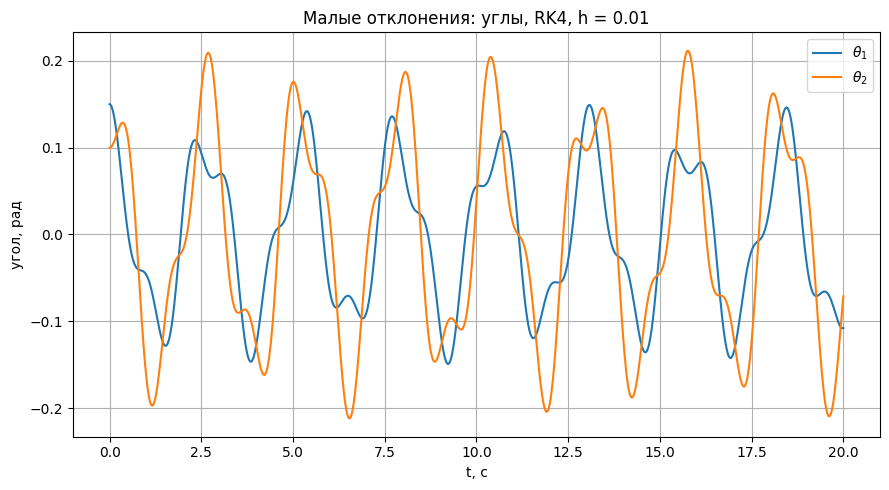

In [5]:

plt.figure()
plt.plot(t_rk, Y_rk[:, 0], label=r"$\theta_1$")
plt.plot(t_rk, Y_rk[:, 2], label=r"$\theta_2$")
plt.xlabel("t, с")
plt.ylabel("угол, рад")
plt.title("Малые отклонения: углы, RK4, h = 0.01")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "small_angles_rk4.png", dpi=160)
plt.show()


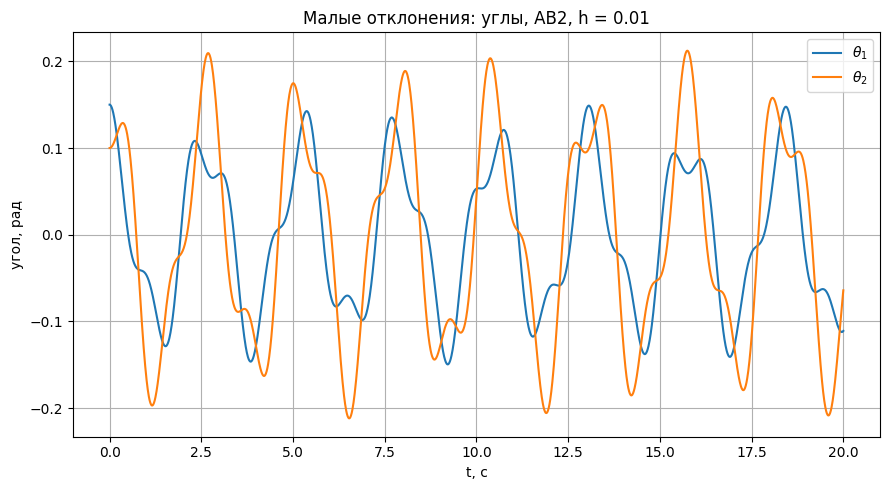

In [6]:

plt.figure()
plt.plot(t_ab, Y_ab[:, 0], label=r"$\theta_1$")
plt.plot(t_ab, Y_ab[:, 2], label=r"$\theta_2$")
plt.xlabel("t, с")
plt.ylabel("угол, рад")
plt.title("Малые отклонения: углы, AB2, h = 0.01")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "small_angles_ab2.png", dpi=160)
plt.show()



Обе координаты колеблются регулярно. Даже при малых углах движение не сводится к одной синусоиде: в системе присутствуют две связанные колебательные моды.


## 5. Траектория нижнего груза

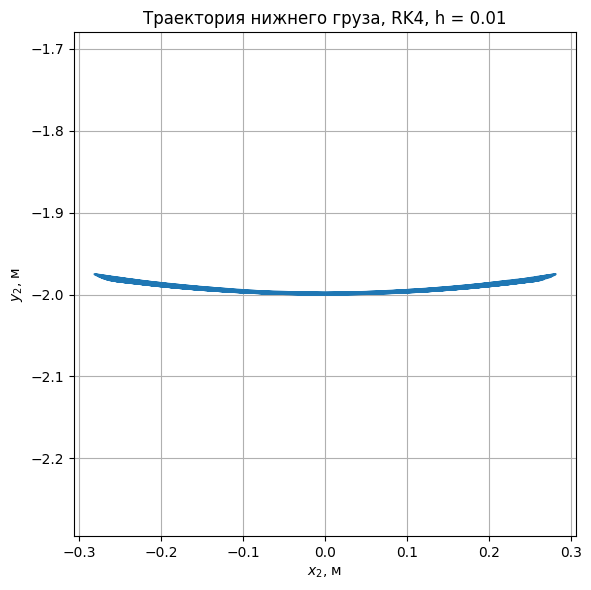

In [7]:

_, _, x2, y2 = bob_coordinates(Y_rk)

plt.figure(figsize=(6, 6))
plt.plot(x2, y2)
plt.xlabel(r"$x_2$, м")
plt.ylabel(r"$y_2$, м")
plt.title("Траектория нижнего груза, RK4, h = 0.01")
plt.axis("equal")
plt.tight_layout()
plt.savefig(OUT / "small_lower_bob_trajectory.png", dpi=160)
plt.show()



Нижний груз движется в небольшой области около нижнего положения. Форма траектории получается сложнее простой дуги из-за связи двух звеньев.


## 6. Сравнение результатов при разных шагах

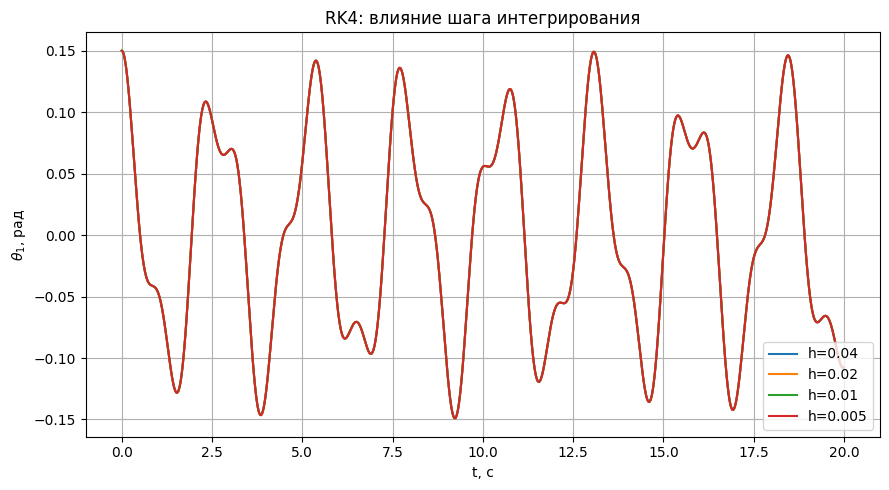

In [8]:

plt.figure()
for h in steps_small:
    t, Y = small_rk4[h]
    plt.plot(t, Y[:, 0], label=f"h={h:g}")
plt.xlabel("t, с")
plt.ylabel(r"$\theta_1$, рад")
plt.title("RK4: влияние шага интегрирования")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "small_step_comparison_rk4.png", dpi=160)
plt.show()


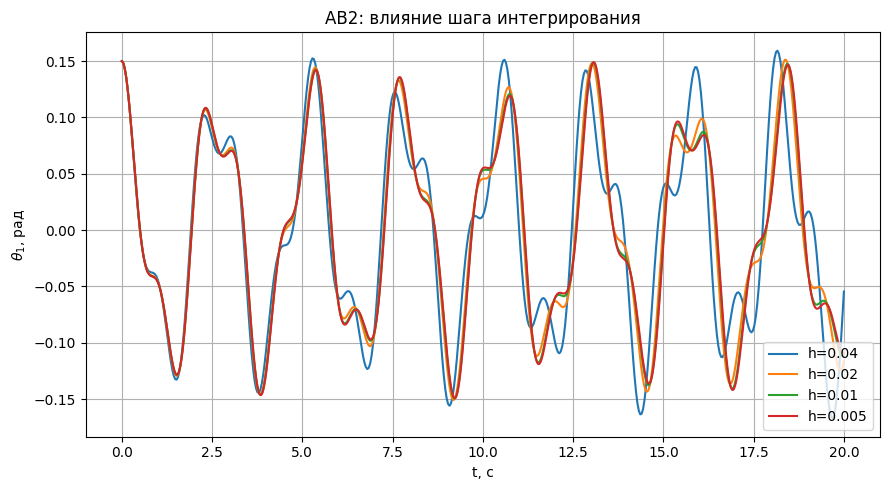

In [9]:

plt.figure()
for h in steps_small:
    t, Y = small_ab2[h]
    plt.plot(t, Y[:, 0], label=f"h={h:g}")
plt.xlabel("t, с")
plt.ylabel(r"$\theta_1$, рад")
plt.title("AB2: влияние шага интегрирования")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "small_step_comparison_ab2.png", dpi=160)
plt.show()



У RK4 кривые при разных шагах практически сливаются раньше. Для AB2 зависимость от шага заметнее, что согласуется с порядками методов: глобальная ошибка RK4 имеет порядок \(O(h^4)\), а AB2 — \(O(h^2)\).


## 7. Полная механическая энергия

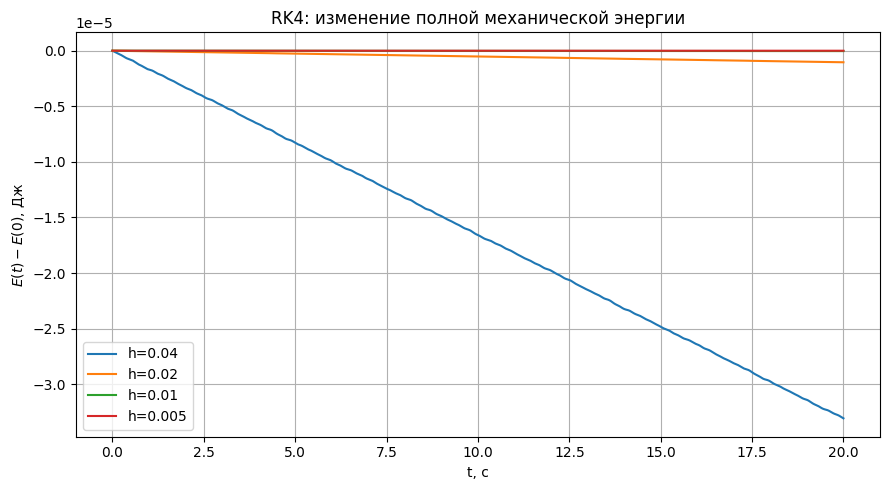

In [10]:

plt.figure()
for h in steps_small:
    t, Y = small_rk4[h]
    E = total_energy(Y)
    plt.plot(t, E - E[0], label=f"h={h:g}")
plt.xlabel("t, с")
plt.ylabel(r"$E(t)-E(0)$, Дж")
plt.title("RK4: изменение полной механической энергии")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "small_energy_rk4.png", dpi=160)
plt.show()


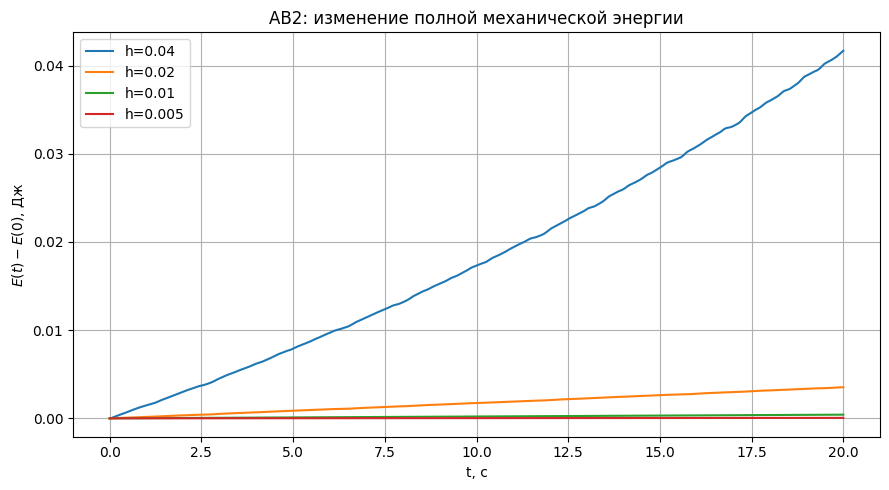

In [11]:

plt.figure()
for h in steps_small:
    t, Y = small_ab2[h]
    E = total_energy(Y)
    plt.plot(t, E - E[0], label=f"h={h:g}")
plt.xlabel("t, с")
plt.ylabel(r"$E(t)-E(0)$, Дж")
plt.title("AB2: изменение полной механической энергии")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "small_energy_ab2.png", dpi=160)
plt.show()


In [12]:

rows = []
for h in steps_small:
    for name, data in [("RK4", small_rk4[h]), ("AB2", small_ab2[h])]:
        t, Y = data
        E = total_energy(Y)
        rel_drift = np.max(np.abs(E - E[0])) / max(abs(E[0]), 1e-15)
        rows.append({
            "method": name,
            "h": h,
            "max relative energy drift": rel_drift
        })

energy_table = pd.DataFrame(rows)
display(energy_table.style.format({"max relative energy drift": "{:.3e}"}))


,method,h,max relative energy drift
0,RK4,0.040000,1.134e-06
1,AB2,0.040000,1.430e-03
2,RK4,0.020000,3.564e-08
3,AB2,0.020000,1.210e-04
4,RK4,0.010000,1.115e-09
5,AB2,0.010000,1.435e-05
6,RK4,0.005000,3.487e-11
7,AB2,0.005000,1.773e-06



При уменьшении шага решения обоих методов сходятся. Для одинакового шага RK4 заметно лучше сохраняет энергию и слабее зависит от \(h\). AB2 также работает корректно, но для сопоставимой точности требует меньшего шага.



# Часть II. Большие отклонения и чувствительность

Для исследования режима больших отклонений выберем начальные условия

$$
\theta_1(0)=2.0,
\qquad
\theta_2(0)=-0.5,
$$

$$
\omega_1(0)=\omega_2(0)=0.
$$

Далее будем изменять только первый начальный угол:

$$
\theta_1(0)
\rightarrow
\theta_1(0)+\varepsilon.
$$

Рассмотрим несколько малых начальных возмущений:

$$
\varepsilon
=
10^{-8},\;
10^{-7},\;
10^{-6},\;
10^{-5}
\; \text{рад}.
$$

В этой части используется метод RK4. Здесь основная задача состоит уже не в сравнении численных методов, а в исследовании чувствительности двойного маятника к малым изменениям начальных условий и в отделении этого эффекта от численной погрешности.


In [13]:

y0_big = np.array([2.0, 0.0, -0.5, 0.0])
T_big = 25.0

h_coarse = 0.0025
h_fine = 0.00125

t_big, Y_big = integrate_rk4(y0_big, T_big, h_coarse)

eps_values = [1e-8, 1e-7, 1e-6, 1e-5]
perturbed = {}

for eps in eps_values:
    y0_p = y0_big.copy()
    y0_p[0] += eps
    perturbed[eps] = integrate_rk4(y0_p, T_big, h_coarse)


## 8. Расхождение решений для разных начальных возмущений

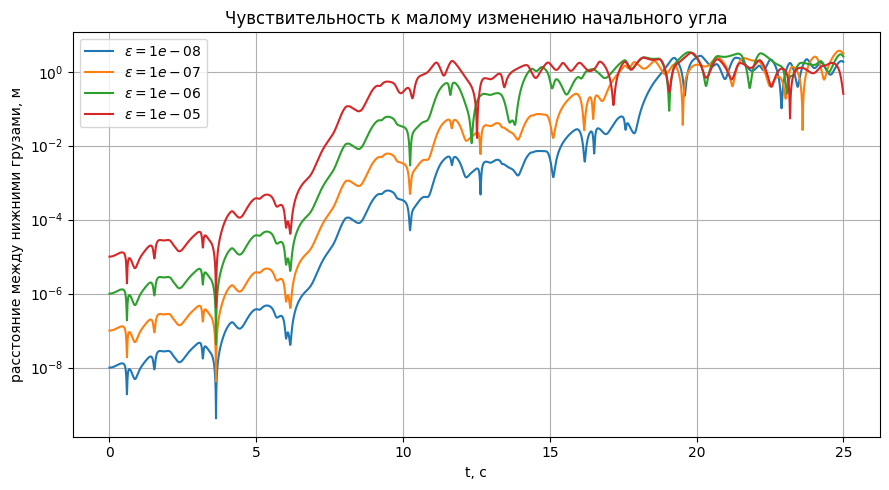

In [14]:

plt.figure()
for eps in eps_values:
    t_p, Y_p = perturbed[eps]
    d = lower_bob_distance(Y_big, Y_p)
    plt.semilogy(t_p, np.maximum(d, 1e-16), label=fr"$\varepsilon={eps:.0e}$")
plt.xlabel("t, с")
plt.ylabel("расстояние между нижними грузами, м")
plt.title("Чувствительность к малому изменению начального угла")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "chaos_initial_perturbations.png", dpi=160)
plt.show()



На логарифмической шкале сначала наблюдается быстрое увеличение различия, а затем насыщение на масштабе, сравнимом с размерами системы. Чем меньше начальное возмущение, тем позже появляется заметное макроскопическое расхождение.



## 9. Отдельная проверка изменения результата при уменьшении шага

Одно и то же начальное условие рассчитывается с шагами
Для проверки влияния шага интегрирования используются два значения:

$$
h = 0.0025,
\qquad
\frac{h}{2} = 0.00125.
$$
В качестве наглядной меры ошибки берётся расстояние между положениями нижнего груза в этих двух расчётах.


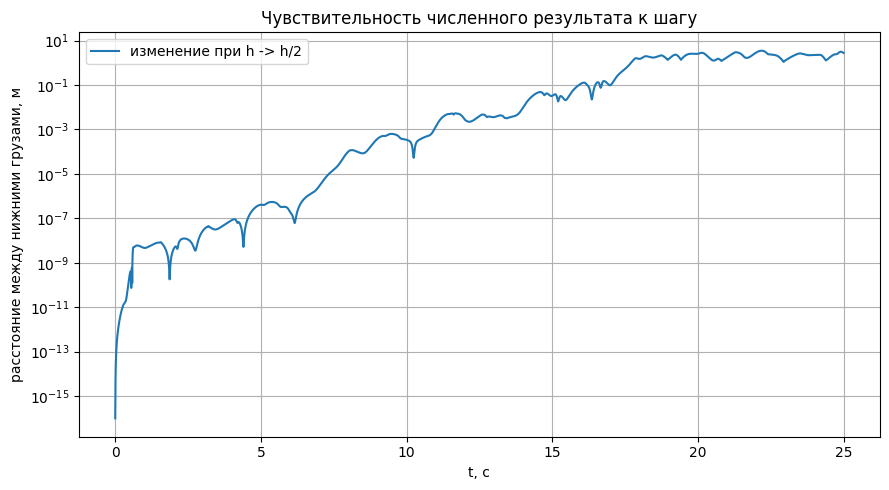

In [15]:

t_fine, Y_fine = integrate_rk4(y0_big, T_big, h_fine)

eps_trust = 1e-6
y0_pert = y0_big.copy()
y0_pert[0] += eps_trust

t_pert_coarse, Y_pert_coarse = integrate_rk4(y0_pert, T_big, h_coarse)
t_pert_fine, Y_pert_fine = integrate_rk4(y0_pert, T_big, h_fine)

ratio = int(round(h_coarse / h_fine))
Y_fine_on_coarse = Y_fine[::ratio][:len(t_big)]
Y_pert_fine_on_coarse = Y_pert_fine[::ratio][:len(t_big)]

step_error_base = lower_bob_distance(Y_big, Y_fine_on_coarse)
step_error_pert = lower_bob_distance(Y_pert_coarse, Y_pert_fine_on_coarse)
step_error = np.maximum(step_error_base, step_error_pert)

physical_divergence = lower_bob_distance(Y_big, Y_pert_coarse)

plt.figure()
plt.semilogy(t_big, np.maximum(step_error, 1e-16), label="изменение при h -> h/2")
plt.xlabel("t, с")
plt.ylabel("расстояние между нижними грузами, м")
plt.title("Чувствительность численного результата к шагу")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "chaos_step_refinement.png", dpi=160)
plt.show()



## 10. Интервал времени, на котором расхождению можно доверять

Обозначим:

Обозначим:

- $D_{\mathrm{phys}}(t)$ — расхождение решений, вызванное изменением начального угла на $10^{-6}$ рад;
- $D_{\mathrm{num}}(t)$ — изменение численного решения при уменьшении шага интегрирования в два раза.

Чтобы отдельные моменты случайного сближения траекторий не влияли на оценку, будем использовать накопленный максимум расхождения:

$$
\widehat{D}(t)
=
\max_{\tau \leq t} D(\tau).
$$

Для оценки интервала достоверности введём следующий критерий:

$$
\widehat{D}_{\mathrm{num}}(t)
<
0.1\,
\widehat{D}_{\mathrm{phys}}(t).
$$

Таким образом, численному расхождению можно доверять до тех пор, пока ошибка, связанная с величиной шага интегрирования, остаётся как минимум в 10 раз меньше расхождения, вызванного изменением начальных условий.
То есть численная неопределённость должна быть хотя бы в 10 раз меньше исследуемого физического расхождения.


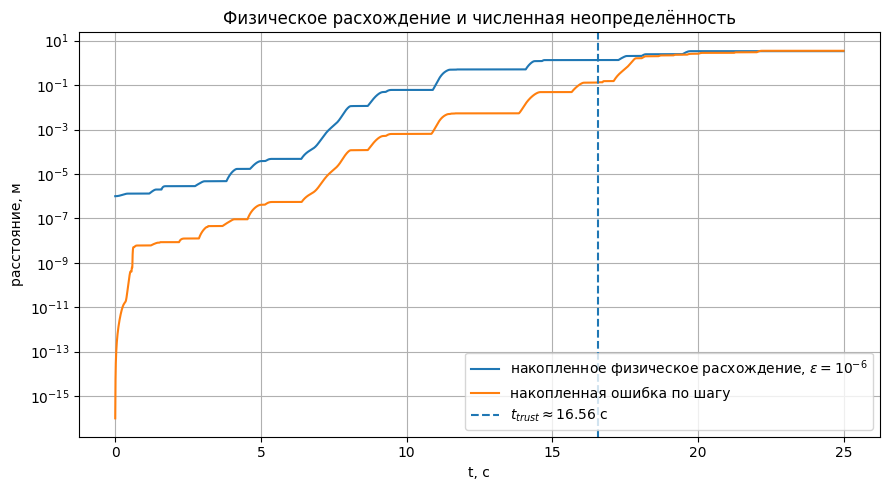

По выбранному 10%-критерию: t_trust ≈ 16.558 с


In [16]:

phys_env = np.maximum.accumulate(physical_divergence)
num_env = np.maximum.accumulate(step_error)

ratio_num_to_phys = num_env / np.maximum(phys_env, eps_trust*l1)

bad = np.where((t_big > 0.5) & (ratio_num_to_phys >= 0.1))[0]
t_trust = t_big[bad[0]] if len(bad) else t_big[-1]

plt.figure()
plt.semilogy(
    t_big,
    np.maximum(phys_env, 1e-16),
    label=r"накопленное физическое расхождение, $\varepsilon=10^{-6}$"
)
plt.semilogy(
    t_big,
    np.maximum(num_env, 1e-16),
    label="накопленная ошибка по шагу"
)
plt.axvline(t_trust, linestyle="--",
            label=fr"$t_{{trust}}\approx {t_trust:.2f}$ с")
plt.xlabel("t, с")
plt.ylabel("расстояние, м")
plt.title("Физическое расхождение и численная неопределённость")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "chaos_trust_interval.png", dpi=160)
plt.show()

print(f"По выбранному 10%-критерию: t_trust ≈ {t_trust:.3f} с")



Для этих начальных условий расчёт даёт горизонт доверия примерно **16–17 с**.

До этого момента расхождение, вызванное малым изменением начального угла, существенно больше оценки ошибки по шагу. После него ошибка дискретизации сама начинает сильно усиливаться.

**Наблюдаемому детальному расхождению траекторий можно доверять только пока сохраняется сходимость при уменьшении шага; в данном расчёте — примерно до 16–17 секунд.**

Важно, что хорошее сохранение энергии само по себе этого не гарантирует: энергия может оставаться почти правильной, а фаза движения уже быть неверной.


## 11. Анимация одного маятника со следом и согласованным графиком углов

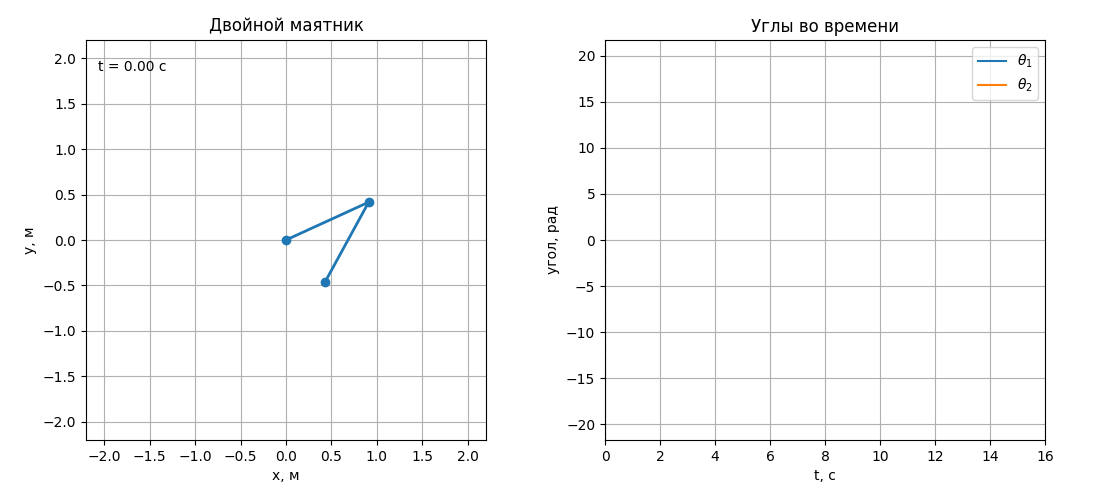

In [17]:
T_anim = 16.0
mask_anim = t_big <= T_anim
t_anim_full = t_big[mask_anim]
Y_anim_full = Y_big[mask_anim]

# 10 кадров/с: плавно и без слишком тяжёлого GIF.
frame_stride = max(1, int(round(0.10 / h_coarse)))
frame_ids = np.arange(0, len(t_anim_full), frame_stride)

x1, y1, x2, y2 = bob_coordinates(Y_anim_full)

fig = plt.figure(figsize=(11, 5))
ax_p = fig.add_axes([0.07, 0.12, 0.38, 0.80])
ax_a = fig.add_axes([0.55, 0.12, 0.40, 0.80])

lim = 1.1*(l1 + l2)
ax_p.set_xlim(-lim, lim)
ax_p.set_ylim(-lim, lim)
ax_p.set_aspect("equal")
ax_p.set_title("Двойной маятник")
ax_p.set_xlabel("x, м")
ax_p.set_ylabel("y, м")
ax_p.grid(True)

rod, = ax_p.plot([], [], "o-", lw=2)
trail, = ax_p.plot([], [], lw=1)
time_text = ax_p.text(0.03, 0.95, "", transform=ax_p.transAxes, va="top")

ax_a.set_xlim(0, T_anim)
angle_lim = 1.1*np.max(np.abs(Y_anim_full[:, [0, 2]]))
ax_a.set_ylim(-angle_lim, angle_lim)
ax_a.set_title("Углы во времени")
ax_a.set_xlabel("t, с")
ax_a.set_ylabel("угол, рад")
ax_a.grid(True)

line_th1, = ax_a.plot([], [], label=r"$\theta_1$")
line_th2, = ax_a.plot([], [], label=r"$\theta_2$")
cursor = ax_a.axvline(0, linestyle="--")
ax_a.legend()

def init_single():
    rod.set_data([], [])
    trail.set_data([], [])
    line_th1.set_data([], [])
    line_th2.set_data([], [])
    cursor.set_xdata([0, 0])
    time_text.set_text("")
    return rod, trail, line_th1, line_th2, cursor, time_text

def update_single(frame_index):
    i = frame_ids[frame_index]
    rod.set_data([0, x1[i], x2[i]], [0, y1[i], y2[i]])

    j0 = max(0, i - int(round(3.0 / h_coarse)))
    trail.set_data(x2[j0:i+1], y2[j0:i+1])

    line_th1.set_data(t_anim_full[:i+1], Y_anim_full[:i+1, 0])
    line_th2.set_data(t_anim_full[:i+1], Y_anim_full[:i+1, 2])

    cursor.set_xdata([t_anim_full[i], t_anim_full[i]])
    time_text.set_text(f"t = {t_anim_full[i]:.2f} с")

    return rod, trail, line_th1, line_th2, cursor, time_text

anim_single = FuncAnimation(
    fig,
    update_single,
    init_func=init_single,
    frames=len(frame_ids),
    interval=100,
    blit=True
)

single_gif = OUT / "double_pendulum_single.gif"
anim_single.save(single_gif, writer=PillowWriter(fps=10))
plt.close(fig)

display(Image(filename=str(single_gif)))


Слева показано движение маятника и след нижнего груза за последние 3 секунды. Справа одновременно строятся $\theta_1(t)$ и $\theta_2(t)$, а вертикальный курсор показывает текущий момент времени.


## 12. Анимация ансамбля из 10 двойных маятников

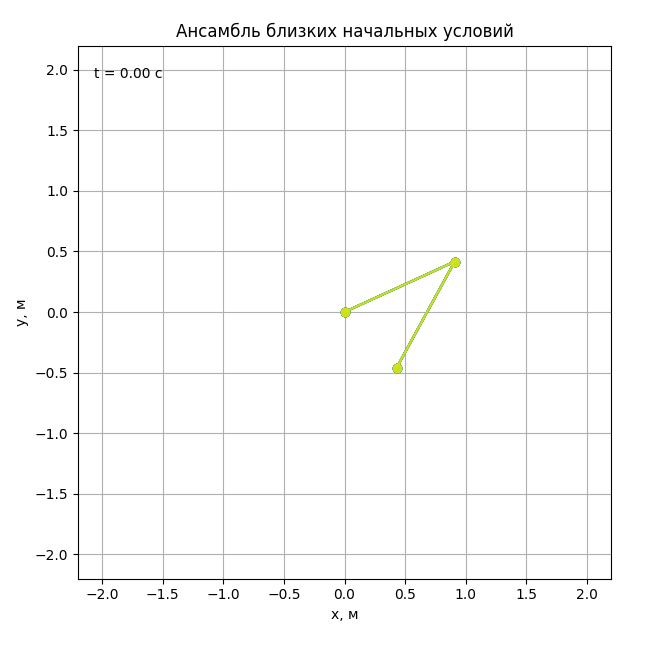

In [18]:
n_ensemble = 10
ensemble_eps = np.linspace(-5e-6, 5e-6, n_ensemble)

ensemble_solutions = []
for eps in ensemble_eps:
    y0_e = y0_big.copy()
    y0_e[0] += eps
    t_e, Y_e = integrate_rk4(y0_e, T_anim, h_coarse)
    ensemble_solutions.append(Y_e)

colors = plt.cm.viridis(np.linspace(0.05, 0.95, n_ensemble))

fig = plt.figure(figsize=(6.5, 6.5))
ax = fig.add_axes([0.12, 0.10, 0.82, 0.84])
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect("equal")
ax.set_xlabel("x, м")
ax.set_ylabel("y, м")
ax.set_title("Ансамбль близких начальных условий")
ax.grid(True)

ensemble_lines = []
for k in range(n_ensemble):
    line, = ax.plot([], [], "o-", lw=1.5, alpha=0.75, color=colors[k])
    ensemble_lines.append(line)

ens_text = ax.text(0.03, 0.96, "", transform=ax.transAxes, va="top")

def init_ensemble():
    for line in ensemble_lines:
        line.set_data([], [])
    ens_text.set_text("")
    return tuple(ensemble_lines) + (ens_text,)

def update_ensemble(frame_index):
    i = frame_ids[frame_index]

    for k, Y_e in enumerate(ensemble_solutions):
        theta1 = Y_e[i, 0]
        theta2 = Y_e[i, 2]

        xx1 = l1*np.sin(theta1)
        yy1 = -l1*np.cos(theta1)
        xx2 = xx1 + l2*np.sin(theta2)
        yy2 = yy1 - l2*np.cos(theta2)

        ensemble_lines[k].set_data([0, xx1, xx2], [0, yy1, yy2])

    ens_text.set_text(f"t = {t_anim_full[i]:.2f} с")
    return tuple(ensemble_lines) + (ens_text,)

anim_ensemble = FuncAnimation(
    fig,
    update_ensemble,
    init_func=init_ensemble,
    frames=len(frame_ids),
    interval=100,
    blit=True
)

ensemble_gif = OUT / "double_pendulum_ensemble.gif"
anim_ensemble.save(ensemble_gif, writer=PillowWriter(fps=10))
plt.close(fig)

display(Image(filename=str(ensemble_gif)))


Сначала десять маятников почти совпадают. Затем различия начального угла величиной всего несколько микрордиан усиливаются, и движения становятся визуально различимыми.
